<a href="https://colab.research.google.com/github/mwaniasam/formative1-working_with_time_series_data/blob/main/Pipeline_formative.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Time-Series Preprocessing, Exploratory Analysis & Model Training
**Dataset:** Hourly Energy Generation, Load & Price Data (Spain, 2015–2018)  
**Source:** Kaggle - ESIOS (Spanish electricity market operator)  
**Target Variable:** `price actual` - Hourly electricity market price (€/MWh)  


## Problem Statement
Electricity price forecasting is a critical challenge in energy markets. Prices fluctuate hourly based on demand, renewable generation, fuel costs, and grid conditions. This project builds a **machine learning pipeline** to forecast the next hour’s electricity price in Spain using historical energy data.

Accurate forecasts help:
- **Energy traders** decide when to buy or sell electricity
- **Grid operators** balance supply and demand in real time
- **Consumers** shift energy usage to cheaper periods

### Why This Dataset?
- Clear **hourly timestamp** covering 4 full years (2015–2018) - 35,064 records
- Meaningful **regression target** (`price actual`) with real market significance
- **26 variables**: generation types (solar, wind, nuclear, gas), total load, and price forecasts
- Rich enough for lag features, moving averages, and seasonal analysis
- Naturally normalises into 3+ relational tables for the database design task

### Notebook Structure
| Section | Content |
|---|---|
| **Task 1A** | Dataset understanding: time range, missing values, statistical distribution |
| **Task 1B** | 6 analytical questions with visualisations |
| **Task 1C** | 4 model experiments: Ridge, Random Forest, LSTM (simple), LSTM (deep) |

### Models Compared (Task 1C):
| # | Model | Type |
|---|-------|------|
| Exp 1 | Ridge Regression | Classical ML (Linear) |
| Exp 2 | Random Forest | Classical ML (Ensemble) |
| Exp 3 | LSTM (1 layer) | Deep Learning |
| Exp 4 | LSTM (2 layers, tuned) | Deep Learning |


## 1. Import Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Classical ML
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
import joblib
import json

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

print(f'TensorFlow version: {tf.__version__}')
print('All libraries imported!')

TensorFlow version: 2.19.0
All libraries imported!



## 2 Mount Drive & Load Dataset

In [33]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
from google.colab import files
uploaded = files.upload()

Saving energy_dataset.csv to energy_dataset (1).csv


In [16]:
df = pd.read_csv('energy_dataset.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
df = df.sort_values('time').reset_index(drop=True)
df.set_index('time', inplace=True)

# Drop fully null columns
all_null_cols = df.columns[df.isnull().all()].tolist()
df.drop(columns=all_null_cols, inplace=True)
print(f'Dropped fully null columns: {all_null_cols}')

# Forward fill small gaps
df.ffill(inplace=True)
df.bfill(inplace=True)

print(f'Shape: {df.shape}')
print(f'Missing values remaining: {df.isnull().sum().sum()}')
df.head(3)

Dropped fully null columns: ['generation hydro pumped storage aggregated', 'forecast wind offshore eday ahead']
Shape: (35064, 26)
Missing values remaining: 0


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage consumption,...,generation solar,generation waste,generation wind offshore,generation wind onshore,forecast solar day ahead,forecast wind onshore day ahead,total load forecast,total load actual,price day ahead,price actual
time,,,,,,,,,,,,,,,,,,,,,
2014-12-31 23:00:00+00:00,447.0,329.0,0.0,4844.0,4821.0,162.0,0.0,0.0,0.0,863.0,...,49.0,196.0,0.0,6378.0,17.0,6436.0,26118.0,25385.0,50.10,65.41
2015-01-01 00:00:00+00:00,449.0,328.0,0.0,5196.0,4755.0,158.0,0.0,0.0,0.0,920.0,...,50.0,195.0,0.0,5890.0,16.0,5856.0,24934.0,24382.0,48.10,64.92
2015-01-01 01:00:00+00:00,448.0,323.0,0.0,4857.0,4581.0,157.0,0.0,0.0,0.0,1164.0,...,50.0,196.0,0.0,5461.0,8.0,5454.0,23515.0,22734.0,47.33,64.48



# TASK 1A: Understanding the Dataset

## 1A.1 Time Range & Frequency

In [35]:
print('=' * 55)
print('  TIME RANGE & FREQUENCY')
print('=' * 55)
print(f'  Start date   : {df.index.min()}')
print(f'  End date     : {df.index.max()}')
print(f'  Total rows   : {len(df):,} hourly records')
print(f'  Duration     : {(df.index.max() - df.index.min()).days} days (~4 years)')
print(f'  Granularity  : Hourly (1 record per hour)')
print(f'  Total columns: {df.shape[1]}')

  TIME RANGE & FREQUENCY
  Start date   : 2015-01-07 23:00:00+00:00
  End date     : 2018-12-31 22:00:00+00:00
  Total rows   : 34,896 hourly records
  Duration     : 1453 days (~4 years)
  Granularity  : Hourly (1 record per hour)
  Total columns: 40


## 1A.2 Missing Values Analysis

Columns with missing values (before handling):
                                             Missing Count  Missing %
generation hydro pumped storage aggregated           35064    100.000
forecast wind offshore eday ahead                    35064    100.000
total load actual                                       36      0.103
generation hydro pumped storage consumption             19      0.054
generation biomass                                      19      0.054
generation fossil oil                                   19      0.054
generation marine                                       19      0.054
generation hydro run-of-river and poundage              19      0.054
generation waste                                        19      0.054
generation fossil oil shale                             18      0.051
generation fossil coal-derived gas                      18      0.051
generation fossil brown coal/lignite                    18      0.051
generation fossil hard coal                

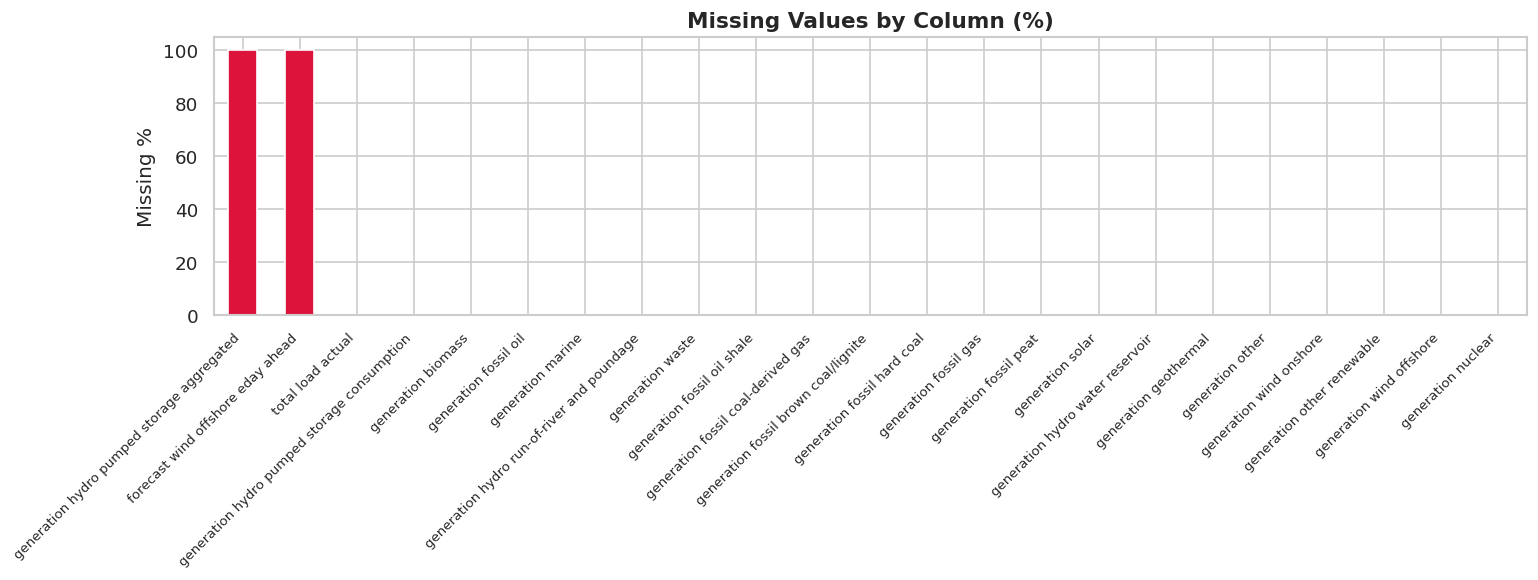

Saved: missing_values.png


In [36]:
df_check = pd.read_csv('energy_dataset.csv')
missing = df_check.isnull().sum()
missing_pct = (missing / len(df_check) * 100).round(3)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print('Columns with missing values (before handling):')
print(missing_df.to_string())

plt.figure(figsize=(13, 5))
colors = ['crimson' if x == 100 else 'steelblue' for x in missing_df['Missing %']]
missing_df['Missing %'].plot(kind='bar', color=colors, edgecolor='white')
plt.title('Missing Values by Column (%)', fontsize=13, fontweight='bold')
plt.ylabel('Missing %')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('missing_values.png', bbox_inches='tight')
plt.show()
print('Saved: missing_values.png')

## 1A.3 Statistical Distribution of Key Columns

Statistical Summary:


,generation biomass,generation fossil brown coal/lignite,generation fossil coal-derived gas,generation fossil gas,generation fossil hard coal,generation fossil oil,generation fossil oil shale,generation fossil peat,generation geothermal,generation hydro pumped storage consumption,...,is_weekend,price_lag_1h,price_lag_24h,price_lag_168h,load_lag_1h,load_lag_24h,price_ma_24h,price_ma_168h,price_std_24h,load_ma_24h
count,34896.00,34896.00,34896.0,34896.00,34896.00,34896.00,34896.0,34896.0,34896.0,34896.00,...,34896.00,34896.00,34896.00,34896.00,34896.00,34896.00,34896.00,34896.00,34896.00,34896.00
mean,383.28,448.79,0.0,5629.81,4259.04,298.43,0.0,0.0,0.0,473.69,...,0.29,57.83,57.84,57.84,28707.81,28711.90,57.84,57.84,7.04,28709.92
std,85.37,354.22,0.0,2203.54,1958.87,52.33,0.0,0.0,0.0,791.22,...,0.45,14.20,14.21,14.21,4575.28,4575.73,12.05,10.87,3.09,2572.67
min,0.00,0.00,0.0,0.00,0.00,0.00,0.0,0.0,0.0,0.00,...,0.00,9.33,9.33,9.33,18041.00,18041.00,13.77,27.92,0.78,21493.62
25%,333.00,0.00,0.0,4131.00,2538.00,263.00,0.0,0.0,0.0,0.00,...,0.00,49.31,49.31,49.30,24815.00,24817.00,50.82,51.67,4.85,27115.15
50%,366.00,510.00,0.0,4977.00,4479.50,300.00,0.0,0.0,0.0,66.00,...,0.00,57.97,57.97,57.96,28919.00,28923.50,58.66,58.98,6.58,28674.35
75%,432.00,757.00,0.0,6438.00,5839.00,330.00,0.0,0.0,0.0,611.00,...,1.00,67.97,67.97,67.96,32204.00,32208.50,66.51,65.92,8.83,30674.09
max,592.00,999.00,0.0,20034.00,8359.00,449.00,0.0,0.0,0.0,4523.00,...,1.00,116.80,116.80,116.80,41015.00,41015.00,99.66,92.34,23.68,35475.12


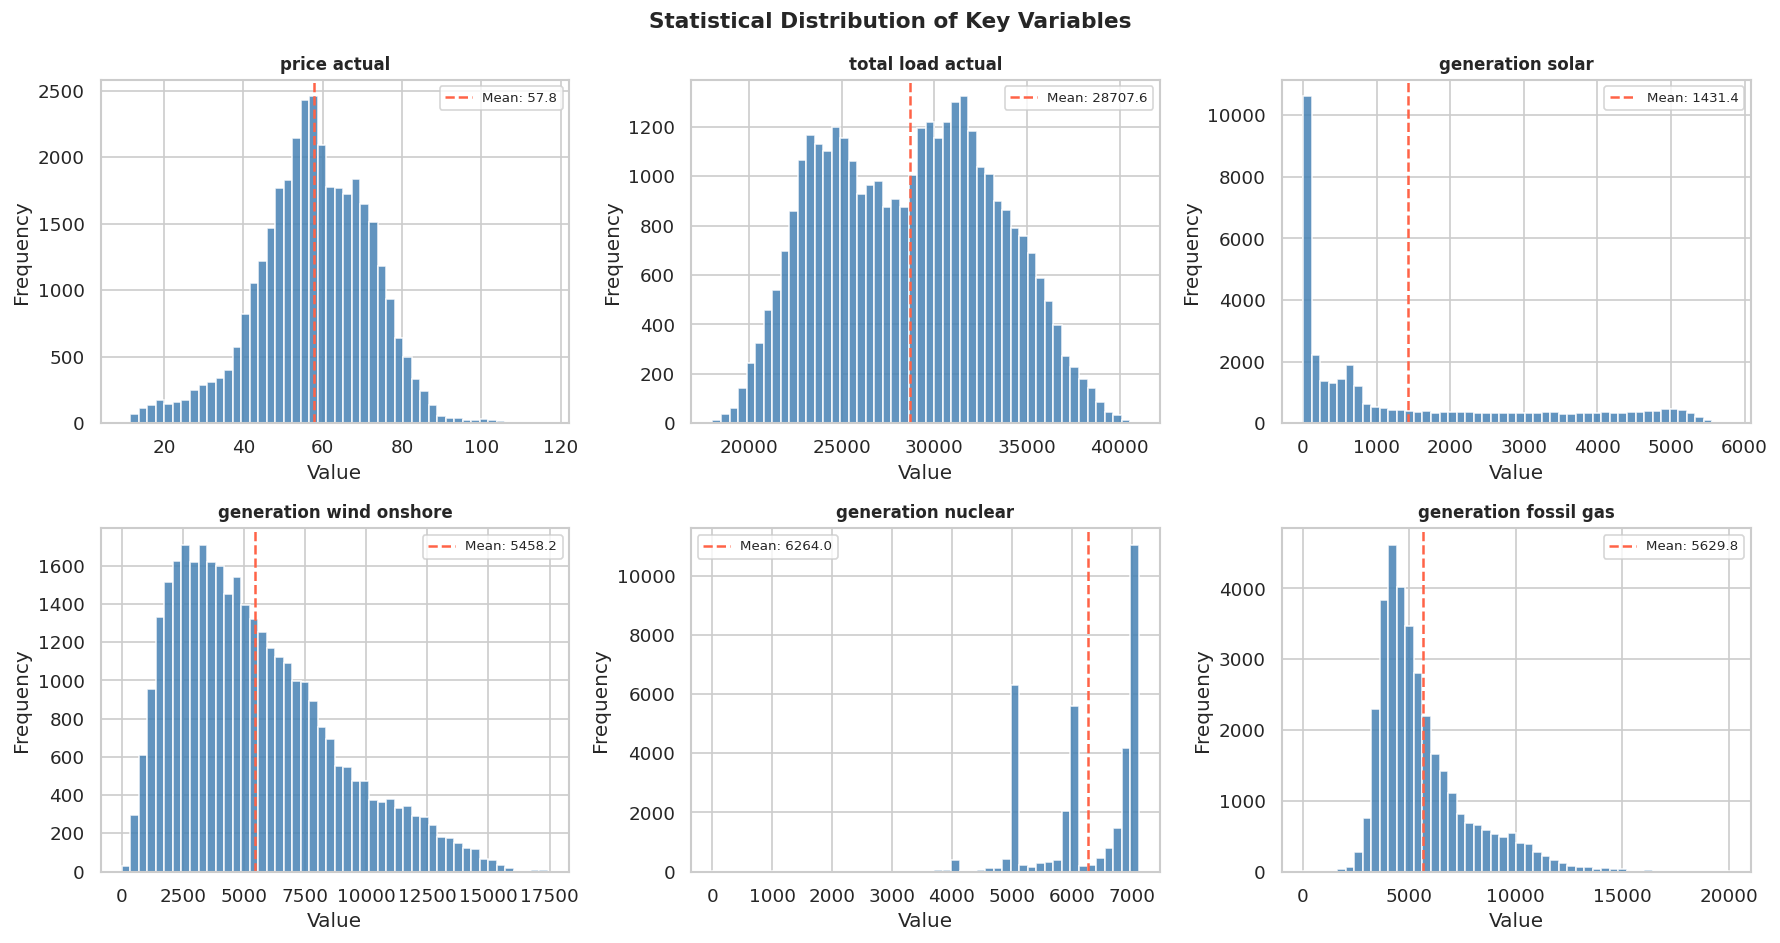

Saved: distributions.png


In [37]:
print('Statistical Summary:')
display(df.describe().round(2))

key_cols = ['price actual', 'total load actual', 'generation solar',
            'generation wind onshore', 'generation nuclear', 'generation fossil gas']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='tomato', linestyle='--', linewidth=1.5,
                    label=f'Mean: {df[col].mean():.1f}')
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].legend(fontsize=8)
plt.suptitle('Statistical Distribution of Key Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('distributions.png', bbox_inches='tight')
plt.show()
print('Saved: distributions.png')


# TASK 1B: Analytical Questions

## Question 1: Does electricity price show an increasing or decreasing trend over 2015–2018?

2015 average price: €61.23/MWh
2016 average price: €47.44/MWh
2017 average price: €59.32/MWh
2018 average price: €63.44/MWh


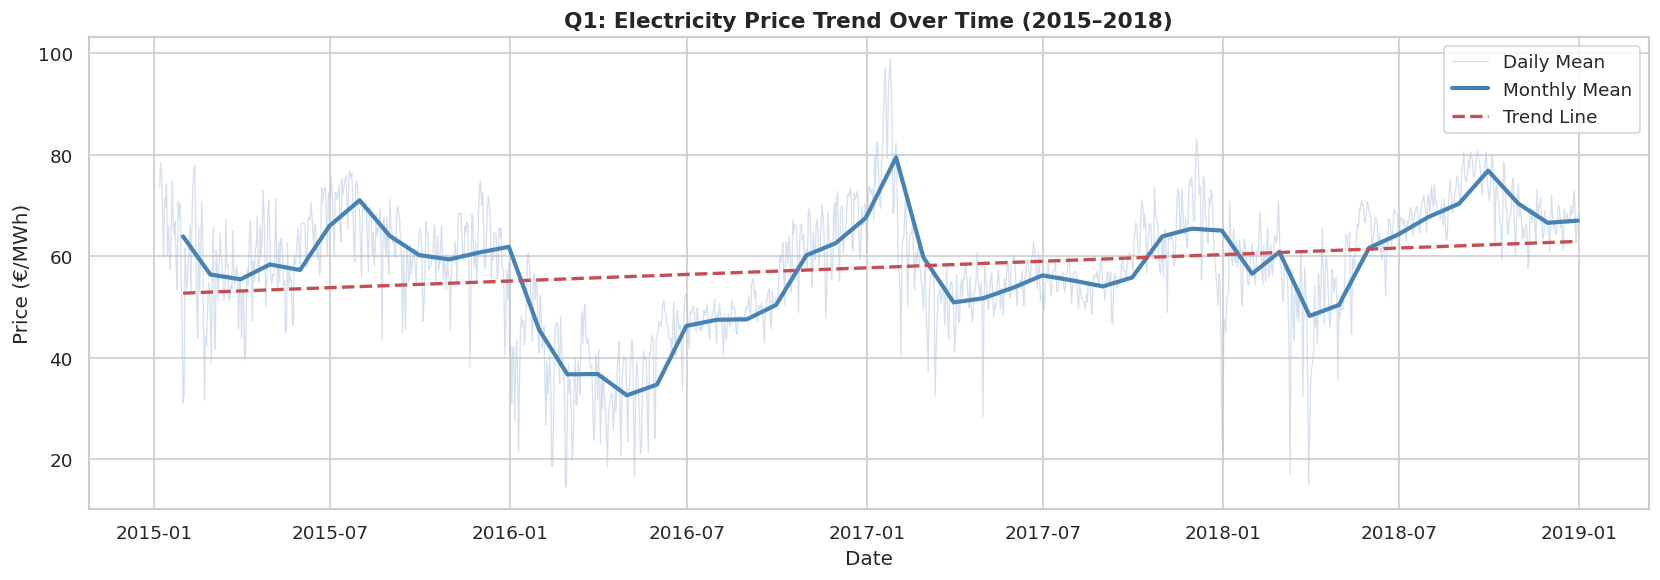

Saved: q1_price_trend.png


In [38]:
daily_price   = df['price actual'].resample('D').mean()
monthly_price = df['price actual'].resample('ME').mean()

for yr in [2015, 2016, 2017, 2018]:
    avg = df[df.index.year == yr]['price actual'].mean()
    print(f'{yr} average price: €{avg:.2f}/MWh')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_price.index, daily_price.values, color='lightsteelblue', alpha=0.5, linewidth=0.8, label='Daily Mean')
ax.plot(monthly_price.index, monthly_price.values, color='steelblue', linewidth=2.5, label='Monthly Mean')
z = np.polyfit(np.arange(len(monthly_price)), monthly_price.values, 1)
p = np.poly1d(z)
ax.plot(monthly_price.index, p(np.arange(len(monthly_price))), 'r--', linewidth=2, label='Trend Line')
ax.set_title('Q1: Electricity Price Trend Over Time (2015–2018)', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Price (€/MWh)')
ax.legend()
plt.tight_layout()
plt.savefig('q1_price_trend.png', bbox_inches='tight')
plt.show()
print('Saved: q1_price_trend.png')

## Question 2: How does electricity price vary by hour of day and day of week?

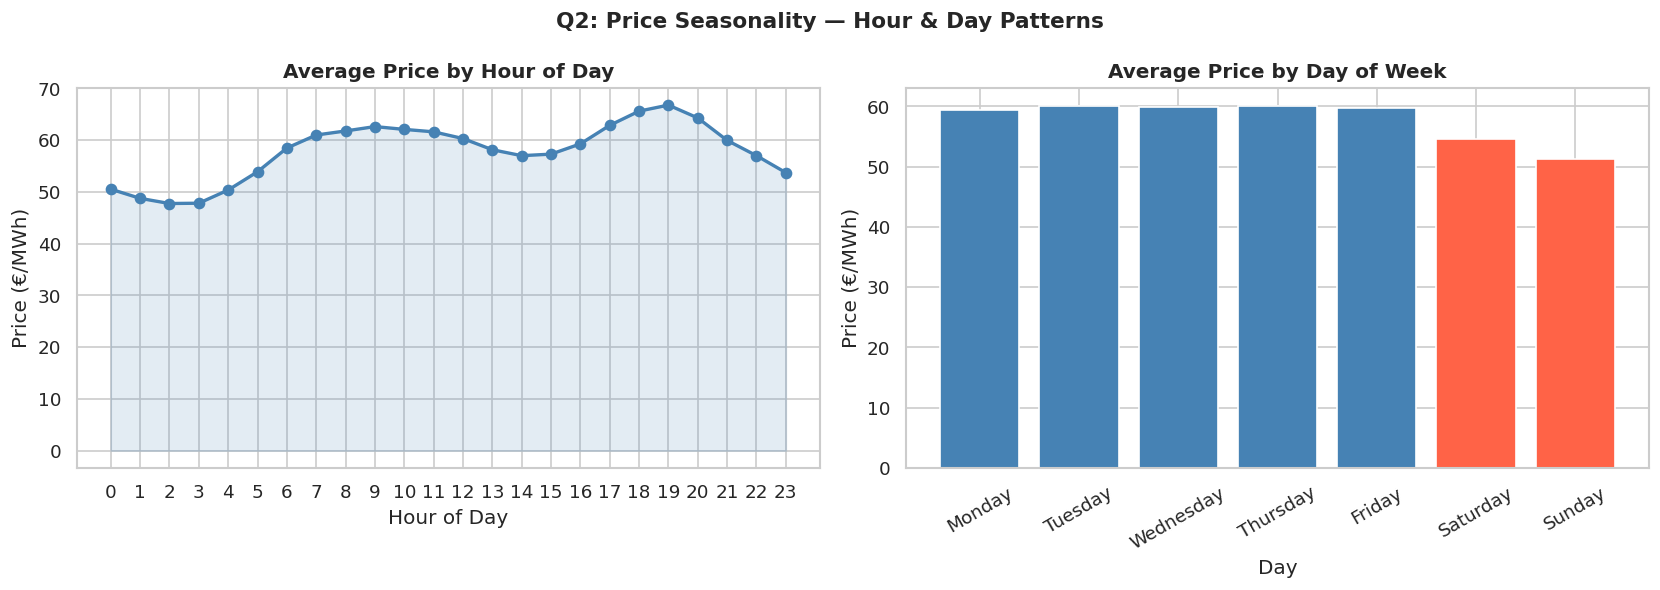

Saved: q2_price_seasonality.png


In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hourly_avg = df.groupby(df.index.hour)['price actual'].mean()
axes[0].plot(hourly_avg.index, hourly_avg.values, marker='o', color='steelblue', linewidth=2)
axes[0].fill_between(hourly_avg.index, hourly_avg.values, alpha=0.15, color='steelblue')
axes[0].set_title('Average Price by Hour of Day', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Price (€/MWh)')
axes[0].set_xticks(range(0, 24))

day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
day_avg = df.groupby(df.index.day_name())['price actual'].mean().reindex(day_order)
colors  = ['steelblue']*5 + ['tomato']*2
axes[1].bar(day_avg.index, day_avg.values, color=colors, edgecolor='white')
axes[1].set_title('Average Price by Day of Week', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Price (€/MWh)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Q2: Price Seasonality — Hour & Day Patterns', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q2_price_seasonality.png', bbox_inches='tight')
plt.show()
print('Saved: q2_price_seasonality.png')

## Question 3: Does total energy demand (load) correlate with electricity price?

Pearson Correlation (Load vs Price): r = 0.4375


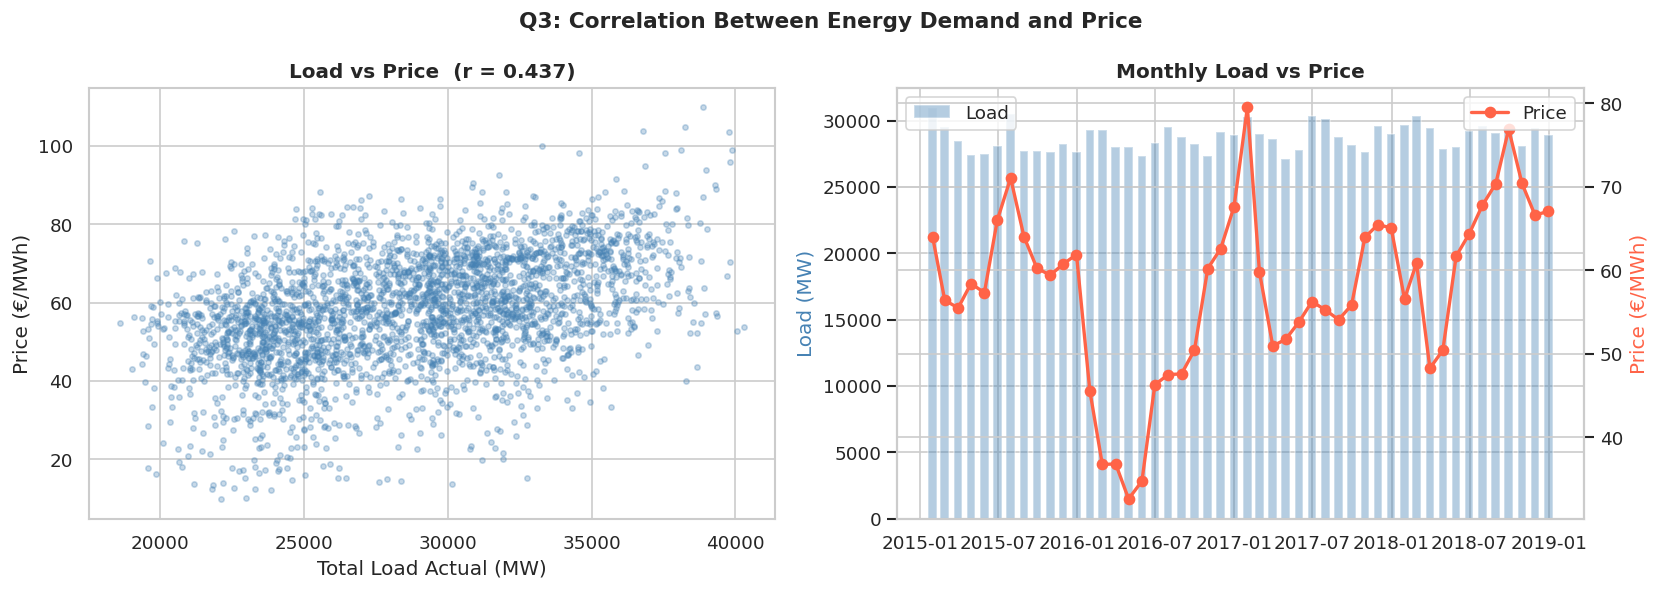

Saved: q3_load_vs_price.png


In [40]:
corr = df['total load actual'].corr(df['price actual'])
print(f'Pearson Correlation (Load vs Price): r = {corr:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df.sample(3000, random_state=42)
axes[0].scatter(sample['total load actual'], sample['price actual'], alpha=0.3, s=10, color='steelblue')
axes[0].set_title(f'Load vs Price  (r = {corr:.3f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Load Actual (MW)')
axes[0].set_ylabel('Price (€/MWh)')

monthly = df[['total load actual','price actual']].resample('ME').mean()
ax2 = axes[1].twinx()
axes[1].bar(monthly.index, monthly['total load actual'], color='steelblue', alpha=0.4, width=20, label='Load')
ax2.plot(monthly.index, monthly['price actual'], color='tomato', linewidth=2, marker='o', label='Price')
axes[1].set_title('Monthly Load vs Price', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Load (MW)', color='steelblue')
ax2.set_ylabel('Price (€/MWh)', color='tomato')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.suptitle('Q3: Correlation Between Energy Demand and Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q3_load_vs_price.png', bbox_inches='tight')
plt.show()
print('Saved: q3_load_vs_price.png')

## Question 4: Are there lag effects - do past prices predict current prices? *(Lag Feature Analysis)*

Lag    1h  →  Correlation: 0.9668
Lag    6h  →  Correlation: 0.6388
Lag   12h  →  Correlation: 0.6727
Lag   24h  →  Correlation: 0.8290
Lag   48h  →  Correlation: 0.7330
Lag  168h  →  Correlation: 0.7887


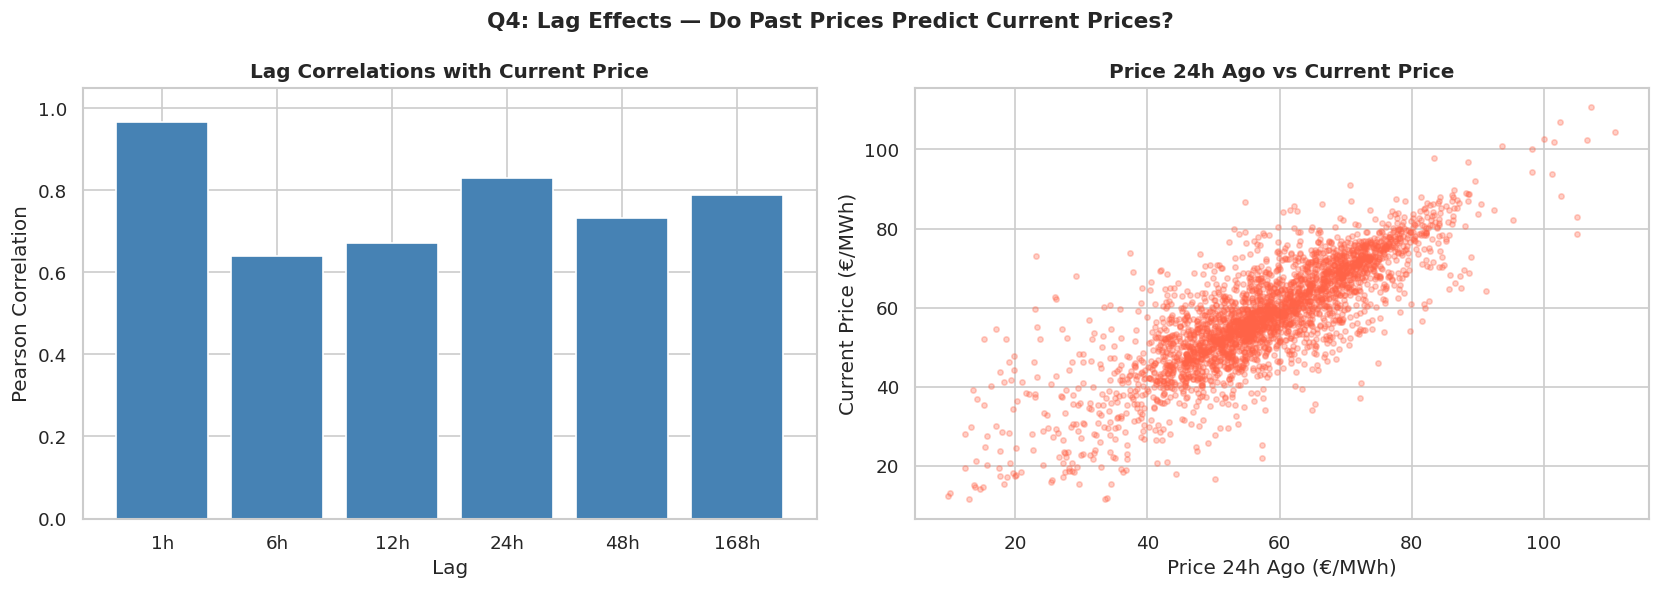

Saved: q4_lag_effects.png


In [41]:
lag_hours = [1, 6, 12, 24, 48, 168]
lag_corrs = {}
for lag in lag_hours:
    c = df['price actual'].corr(df['price actual'].shift(lag))
    lag_corrs[lag] = c
    print(f'Lag {lag:>4}h  →  Correlation: {c:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar([str(l)+'h' for l in lag_hours], lag_corrs.values(), color='steelblue', edgecolor='white')
axes[0].set_title('Lag Correlations with Current Price', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Pearson Correlation')
axes[0].set_ylim(0, 1.05)

tmp = df[['price actual']].copy()
tmp['lag_24h'] = df['price actual'].shift(24)
tmp = tmp.dropna().sample(3000, random_state=42)
axes[1].scatter(tmp['lag_24h'], tmp['price actual'], alpha=0.3, s=10, color='tomato')
axes[1].set_title('Price 24h Ago vs Current Price', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Price 24h Ago (€/MWh)')
axes[1].set_ylabel('Current Price (€/MWh)')

plt.suptitle('Q4: Lag Effects — Do Past Prices Predict Current Prices?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q4_lag_effects.png', bbox_inches='tight')
plt.show()
print('Saved: q4_lag_effects.png')

## Question 5: How do moving averages reveal price trends and volatility? *(Moving Average Analysis)*

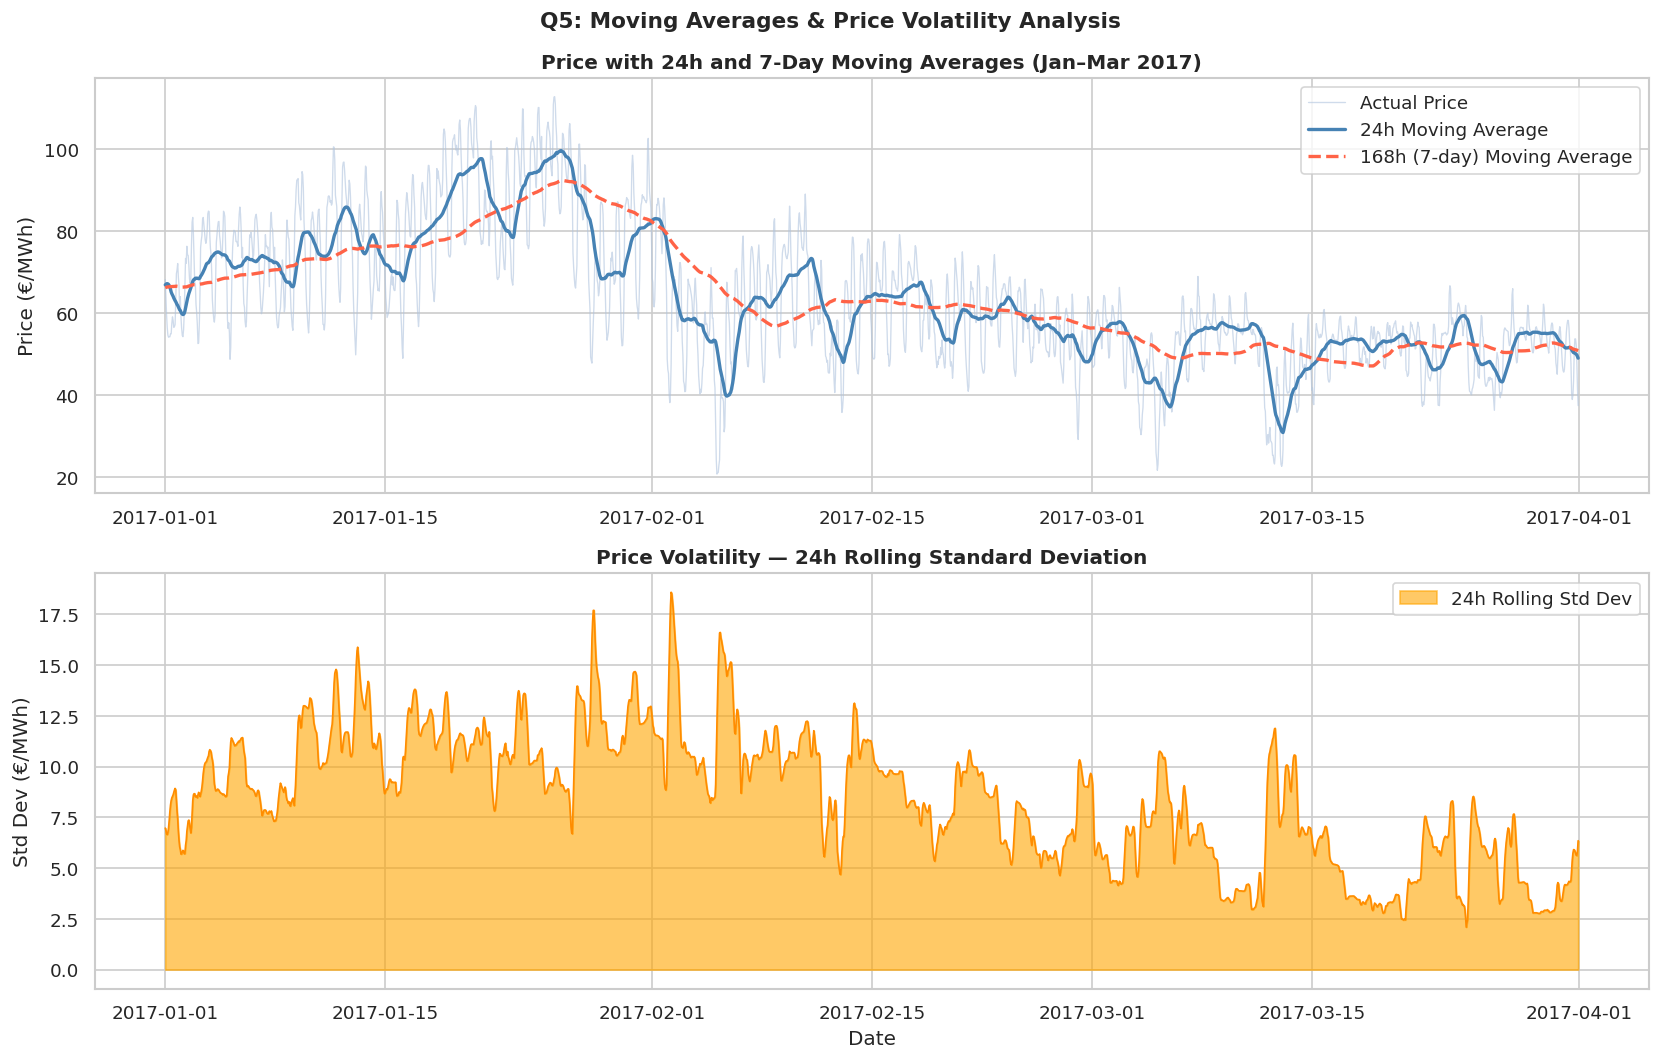

Saved: q5_moving_averages.png


In [42]:
df['price_ma_24h_eda']  = df['price actual'].rolling(24).mean()
df['price_ma_168h_eda'] = df['price actual'].rolling(168).mean()
df['price_std_24h_eda'] = df['price actual'].rolling(24).std()

window = df['2017-01-01':'2017-03-31']

fig, axes = plt.subplots(2, 1, figsize=(14, 9))
axes[0].plot(window.index, window['price actual'], color='lightsteelblue', alpha=0.6, linewidth=0.8, label='Actual Price')
axes[0].plot(window.index, window['price_ma_24h_eda'], color='steelblue', linewidth=2, label='24h Moving Average')
axes[0].plot(window.index, window['price_ma_168h_eda'], color='tomato', linewidth=2, linestyle='--', label='168h (7-day) Moving Average')
axes[0].set_title('Price with 24h and 7-Day Moving Averages (Jan–Mar 2017)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (€/MWh)')
axes[0].legend()

axes[1].fill_between(window.index, window['price_std_24h_eda'], color='orange', alpha=0.6, label='24h Rolling Std Dev')
axes[1].plot(window.index, window['price_std_24h_eda'], color='darkorange', linewidth=1)
axes[1].set_title('Price Volatility — 24h Rolling Standard Deviation', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Std Dev (€/MWh)')
axes[1].set_xlabel('Date')
axes[1].legend()

plt.suptitle('Q5: Moving Averages & Price Volatility Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q5_moving_averages.png', bbox_inches='tight')
plt.show()
print('Saved: q5_moving_averages.png')

# Drop EDA-only columns so they don't interfere with modelling
df.drop(columns=['price_ma_24h_eda', 'price_ma_168h_eda', 'price_std_24h_eda'], inplace=True)

## Question 6: Does higher renewable generation (solar + wind) lower electricity prices?

Correlation (Renewable vs Price): r = -0.1641


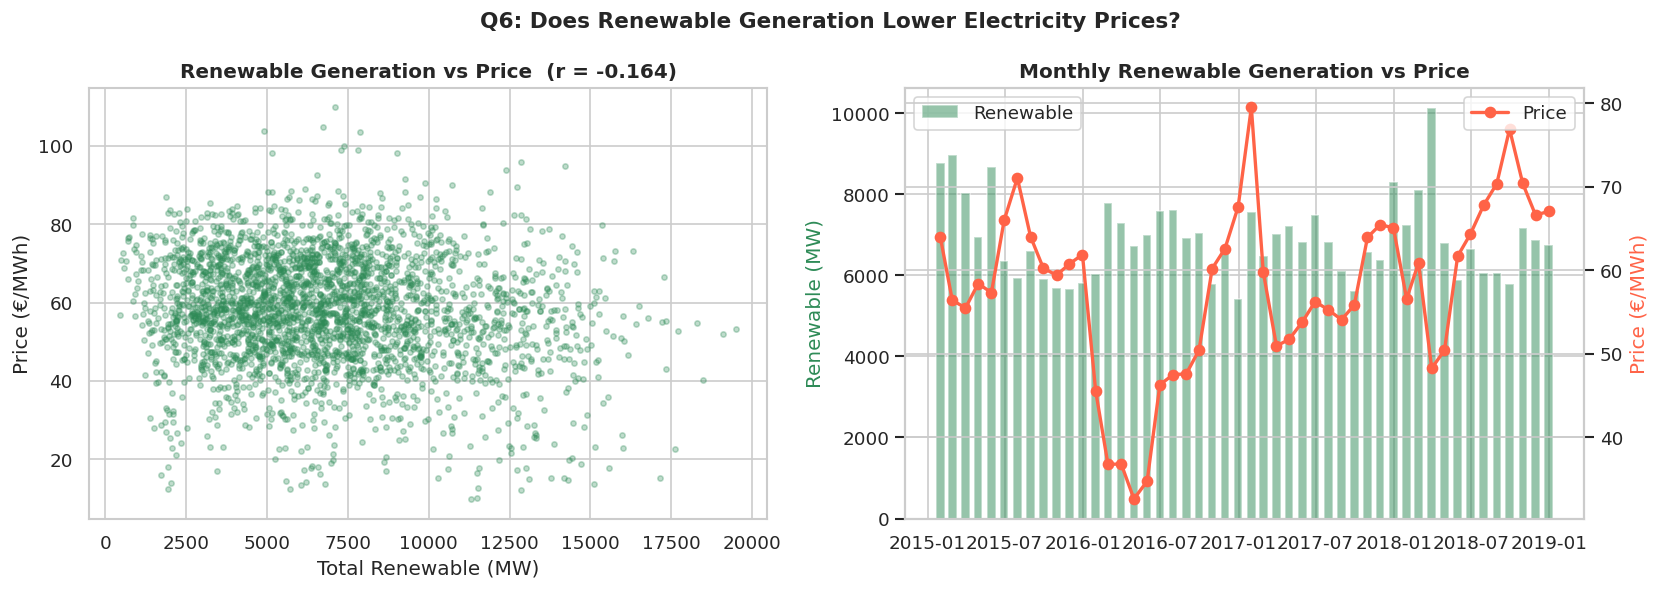

Saved: q6_renewables_vs_price.png


In [43]:
df['total_renewable'] = df['generation solar'] + df['generation wind onshore']
corr_r = df['total_renewable'].corr(df['price actual'])
print(f'Correlation (Renewable vs Price): r = {corr_r:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = df.sample(3000, random_state=42)
axes[0].scatter(sample['total_renewable'], sample['price actual'], alpha=0.3, s=10, color='seagreen')
axes[0].set_title(f'Renewable Generation vs Price  (r = {corr_r:.3f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Total Renewable (MW)')
axes[0].set_ylabel('Price (€/MWh)')

monthly_r = df[['total_renewable','price actual']].resample('ME').mean()
ax2 = axes[1].twinx()
axes[1].bar(monthly_r.index, monthly_r['total_renewable'], color='seagreen', alpha=0.5, width=20, label='Renewable')
ax2.plot(monthly_r.index, monthly_r['price actual'], color='tomato', linewidth=2, marker='o', label='Price')
axes[1].set_title('Monthly Renewable Generation vs Price', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Renewable (MW)', color='seagreen')
ax2.set_ylabel('Price (€/MWh)', color='tomato')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.suptitle('Q6: Does Renewable Generation Lower Electricity Prices?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('q6_renewables_vs_price.png', bbox_inches='tight')
plt.show()
print('Saved: q6_renewables_vs_price.png')

df.drop(columns=['total_renewable'], inplace=True)


## 3. Feature Engineering

In [17]:
# Time features
df['hour']        = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['month']       = df.index.month
df['quarter']     = df.index.quarter
df['is_weekend']  = (df.index.dayofweek >= 5).astype(int)

# Lag features
# Price lags: 1h ago, 24h ago (same hour yesterday), 168h ago (same hour last week)
for lag in [1, 24, 168]:
    df[f'price_lag_{lag}h'] = df['price actual'].shift(lag)

# Load lags
for lag in [1, 24]:
    df[f'load_lag_{lag}h'] = df['total load actual'].shift(lag)

# Moving average features
# shift(1) ensures no data leakage — we only use past values
df['price_ma_24h']  = df['price actual'].shift(1).rolling(24).mean()
df['price_ma_168h'] = df['price actual'].shift(1).rolling(168).mean()
df['price_std_24h'] = df['price actual'].shift(1).rolling(24).std()
df['load_ma_24h']   = df['total load actual'].shift(1).rolling(24).mean()

# Drop NaN rows from lag/rolling
df.dropna(inplace=True)
print(f'Final shape after feature engineering: {df.shape}')

Final shape after feature engineering: (34896, 40)


---
## 4. Define Features & Target

In [18]:
TARGET   = 'price actual'
DROP_COLS = ['price day ahead']  # forward-looking — would cause data leakage

FEATURES = [col for col in df.columns if col != TARGET and col not in DROP_COLS]

X = df[FEATURES].values
y = df[TARGET].values

print(f'Number of features : {len(FEATURES)}')
print(f'Features           : {FEATURES}')
print(f'Total samples      : {len(X):,}')

Number of features : 38
Features           : ['generation biomass', 'generation fossil brown coal/lignite', 'generation fossil coal-derived gas', 'generation fossil gas', 'generation fossil hard coal', 'generation fossil oil', 'generation fossil oil shale', 'generation fossil peat', 'generation geothermal', 'generation hydro pumped storage consumption', 'generation hydro run-of-river and poundage', 'generation hydro water reservoir', 'generation marine', 'generation nuclear', 'generation other', 'generation other renewable', 'generation solar', 'generation waste', 'generation wind offshore', 'generation wind onshore', 'forecast solar day ahead', 'forecast wind onshore day ahead', 'total load forecast', 'total load actual', 'hour', 'day_of_week', 'month', 'quarter', 'is_weekend', 'price_lag_1h', 'price_lag_24h', 'price_lag_168h', 'load_lag_1h', 'load_lag_24h', 'price_ma_24h', 'price_ma_168h', 'price_std_24h', 'load_ma_24h']
Total samples      : 34,896


---
## 5. Train / Test Split (Chronological — No Shuffle)

In [19]:
split_idx = int(len(X) * 0.8)

X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
y_train,     y_test     = y[:split_idx], y[split_idx:]

train_dates = df.index[:split_idx]
test_dates  = df.index[split_idx:]

print(f'Training : {len(X_train_raw):,} samples  |  {train_dates[0].date()} → {train_dates[-1].date()}')
print(f'Testing  : {len(X_test_raw):,} samples  |  {test_dates[0].date()} → {test_dates[-1].date()}')

Training : 27,916 samples  |  2015-01-07 → 2018-03-16
Testing  : 6,980 samples  |  2018-03-16 → 2018-12-31


---
## 6. Scaling
- **StandardScaler** for classical ML models
- **MinMaxScaler** for LSTM (neural networks prefer data in [0,1] range)

In [20]:
# For classical ML
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train_raw)
X_test_std  = std_scaler.transform(X_test_raw)

# For LSTM — scale features and target separately
mm_scaler_X = MinMaxScaler()
mm_scaler_y = MinMaxScaler()

X_train_mm = mm_scaler_X.fit_transform(X_train_raw)
X_test_mm  = mm_scaler_X.transform(X_test_raw)
y_train_mm = mm_scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_mm  = mm_scaler_y.transform(y_test.reshape(-1, 1)).flatten()

# Save scalers for Task 4
joblib.dump(std_scaler, 'scaler_standard.pkl')
joblib.dump(mm_scaler_X, 'scaler_minmax_X.pkl')
joblib.dump(mm_scaler_y, 'scaler_minmax_y.pkl')
print('Scalers saved.')

Scalers saved.


---
## 7. Evaluation Helper

In [21]:
results_log = []

def evaluate(name, y_true, y_pred, hyperparams='', notes=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    sep  = '=' * 55        # ← fix: define separator outside f-string
    print(f'\n{sep}')
    print(f' {name}')
    print(f'{sep}')
    print(f'  MAE  : {mae:.4f} €/MWh')
    print(f'  RMSE : {rmse:.4f} €/MWh')
    print(f'  R²   : {r2:.4f}')
    results_log.append({
        'Model': name,
        'Hyperparameters': hyperparams,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R²': round(r2, 4),
        'Notes': notes
    })
    return y_pred

---
# CLASSICAL ML MODELS

## Experiment 1 — Ridge Regression
**Why:** Fast baseline. Applies L2 regularization to handle multicollinearity between energy features.

In [22]:
ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
ridge_grid   = GridSearchCV(Ridge(), ridge_params, cv=5,
                            scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_std, y_train)

best_ridge    = ridge_grid.best_estimator_
best_alpha    = ridge_grid.best_params_['alpha']
y_pred_ridge  = best_ridge.predict(X_test_std)

print(f'Best alpha: {best_alpha}')
evaluate('Exp 1: Ridge Regression',
         y_test, y_pred_ridge,
         hyperparams=f'alpha={best_alpha}',
         notes='Regularized linear model — baseline')

joblib.dump(best_ridge, 'model_ridge.pkl')
print('Saved: model_ridge.pkl')

Best alpha: 10.0

 Exp 1: Ridge Regression
  MAE  : 1.6686 €/MWh
  RMSE : 2.3542 €/MWh
  R²   : 0.9579
Saved: model_ridge.pkl


## Experiment 2 — Random Forest
**Why:** Ensemble of decision trees, captures non-linear relationships and feature interactions that Ridge misses.

In [23]:
rf_params = {
    'n_estimators':    [100, 200],
    'max_depth':       [10, 20, None],
    'min_samples_split': [2, 5]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42), rf_params,
                       cv=3, scoring='neg_mean_squared_error',
                       n_jobs=-1, verbose=1)
rf_grid.fit(X_train_std, y_train)

best_rf   = rf_grid.best_estimator_
best_rf_p = rf_grid.best_params_
y_pred_rf = best_rf.predict(X_test_std)

print(f'Best params: {best_rf_p}')
evaluate('Exp 2: Random Forest',
         y_test, y_pred_rf,
         hyperparams=str(best_rf_p),
         notes='Ensemble — handles non-linearity')

joblib.dump(best_rf, 'model_random_forest.pkl')
print('Saved: model_random_forest.pkl')

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

 Exp 2: Random Forest
  MAE  : 1.7759 €/MWh
  RMSE : 2.3647 €/MWh
  R²   : 0.9575
Saved: model_random_forest.pkl


---
# DEEP LEARNING — LSTM
LSTM (Long Short-Term Memory) is specifically designed for sequential/time-series data. Unlike classical ML models that treat each row independently, LSTM learns from sequences of past timesteps — making it naturally suited for energy price forecasting.

## Prepare Sequences for LSTM
LSTM expects 3D input: `(samples, timesteps, features)`  
We use a **lookback window of 24 hours** — the model sees the past 24 hours to predict the next hour.

In [24]:
LOOKBACK = 24  # use past 24 hours as input window

def create_sequences(X, y, lookback):
    """Convert flat arrays into overlapping sequences for LSTM."""
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

# Build sequences from MinMax-scaled data
X_seq_all = np.concatenate([X_train_mm, X_test_mm], axis=0)
y_seq_all = np.concatenate([y_train_mm, y_test_mm], axis=0)

X_seq, y_seq = create_sequences(X_seq_all, y_seq_all, LOOKBACK)

# Chronological split for sequences
seq_split = split_idx - LOOKBACK
X_seq_train, X_seq_test = X_seq[:seq_split], X_seq[seq_split:]
y_seq_train, y_seq_test = y_seq[:seq_split], y_seq[seq_split:]

# Get original-scale y_test for evaluation
y_test_lstm = y_test[LOOKBACK:]

print(f'LSTM input shape  : {X_seq_train.shape}  →  (samples, timesteps={LOOKBACK}, features={len(FEATURES)})')
print(f'LSTM train samples: {X_seq_train.shape[0]:,}')
print(f'LSTM test  samples: {X_seq_test.shape[0]:,}')

LSTM input shape  : (27892, 24, 38)  →  (samples, timesteps=24, features=38)
LSTM train samples: 27,892
LSTM test  samples: 6,980


## Experiment 3 — LSTM (Single Layer, Baseline)
**Architecture:** 1 LSTM layer (64 units) → Dense output  
**Why start simple:** Establish a DL baseline before adding complexity.

In [25]:
tf.random.set_seed(42)

def build_lstm_simple(input_shape, lstm_units=64, learning_rate=0.001):
    model = Sequential([
        LSTM(lstm_units, input_shape=input_shape, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

input_shape = (LOOKBACK, len(FEATURES))
lstm_simple = build_lstm_simple(input_shape, lstm_units=64, learning_rate=0.001)
lstm_simple.summary()

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Train
history_simple = lstm_simple.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

# Predict & inverse transform
y_pred_lstm_simple_scaled = lstm_simple.predict(X_seq_test).flatten()
y_pred_lstm_simple = mm_scaler_y.inverse_transform(
    y_pred_lstm_simple_scaled.reshape(-1, 1)
).flatten()

# Fix: align y_test_lstm to match prediction length
y_test_lstm = y_test[-len(y_pred_lstm_simple):]

evaluate('Exp 3: LSTM (1 Layer, 64 units)',
         y_test_lstm, y_pred_lstm_simple,
         hyperparams='units=64, lr=0.001, dropout=0.2, lookback=24',
         notes='Baseline LSTM — single layer')

lstm_simple.save('model_lstm_simple.keras')
print('Saved: model_lstm_simple.keras')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        26,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,481 (111.25 KB)

 Trainable params: 28,481 (111.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 0.0248 - mae: 0.1059 - val_loss: 0.0081 - val_mae: 0.0719
Epoch 2/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0043 - mae: 0.0506 - val_loss: 0.0050 - val_mae: 0.0542
Epoch 3/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0031 - mae: 0.0428 - val_loss: 0.0034 - val_mae: 0.0436
Epoch 4/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0025 - mae: 0.0384 - val_loss: 0.0028 - val_mae: 0.0396
Epoch 5/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0022 - mae: 0.0359 - val_loss: 0.0028 - val_mae: 0.0400
Epoch 6/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - loss: 0.0019 - mae: 0.0333 - val_loss: 0.0025 - val_mae: 0.0373
Epoch 7/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0017 - mae: 0.0310 - val_loss: 0.0023 - val_mae: 0.0357
Epoch 8/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - loss: 0.0016 - mae: 0.0298 - val_loss: 0.0022 - val_mae: 0.0353
Epoch 9/50
393/393 ━━━━━━━━━━━━━━━━━━━━ 10s 19m

## Experiment 4 — LSTM (2 Layers, Tuned)
**Architecture:** 2 stacked LSTM layers + BatchNormalization + Dropout → Dense output  
**Why deeper:** Stacked LSTMs learn both low-level hourly patterns (layer 1) and higher-level multi-day trends (layer 2).  
**Tuned:** More units, lower learning rate, ReduceLROnPlateau callback.

In [26]:
tf.random.set_seed(42)

def build_lstm_deep(input_shape, units_1=128, units_2=64, lr=0.0005, dropout=0.3):
    model = Sequential([
        # Layer 1 — return sequences so layer 2 gets full sequence
        LSTM(units_1, input_shape=input_shape, return_sequences=True),
        BatchNormalization(),
        Dropout(dropout),

        # Layer 2 — final LSTM layer
        LSTM(units_2, return_sequences=False),
        BatchNormalization(),
        Dropout(dropout),

        # Output layers
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='mse',
        metrics=['mae']
    )
    return model

lstm_deep = build_lstm_deep(input_shape, units_1=128, units_2=64, lr=0.0005, dropout=0.3)
lstm_deep.summary()

# Callbacks
early_stop2 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr   = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3,
                                min_lr=1e-6, verbose=1)

# Train
history_deep = lstm_deep.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop2, reduce_lr],
    verbose=1
)

# Predict & inverse transform
y_pred_lstm_deep_scaled = lstm_deep.predict(X_seq_test).flatten()
y_pred_lstm_deep = mm_scaler_y.inverse_transform(
    y_pred_lstm_deep_scaled.reshape(-1, 1)
).flatten()

evaluate('Exp 4: LSTM (2 Layers, Tuned)',
         y_test_lstm, y_pred_lstm_deep,
         hyperparams='units=[128,64], lr=0.0005, dropout=0.3, lookback=24, batch=32',
         notes='Deep stacked LSTM — best performing model')

lstm_deep.save('model_lstm_deep.keras')
print('Saved: model_lstm_deep.keras')

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 24, 128)        │        85,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141,953 (554.50 KB)

 Trainable params: 141,569 (553.00 KB)

 Non-trainable params: 384 (1.50 KB)

Epoch 1/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 83s 98ms/step - loss: 0.0817 - mae: 0.2083 - val_loss: 0.0192 - val_mae: 0.1152 - learning_rate: 5.0000e-04
Epoch 2/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 55s 64ms/step - loss: 0.0127 - mae: 0.0887 - val_loss: 0.0119 - val_mae: 0.0881 - learning_rate: 5.0000e-04
Epoch 3/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 78s 59ms/step - loss: 0.0080 - mae: 0.0695 - val_loss: 0.0090 - val_mae: 0.0757 - learning_rate: 5.0000e-04
Epoch 4/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 42s 54ms/step - loss: 0.0059 - mae: 0.0594 - val_loss: 0.0058 - val_mae: 0.0583 - learning_rate: 5.0000e-04
Epoch 5/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 47s 60ms/step - loss: 0.0046 - mae: 0.0524 - val_loss: 0.0045 - val_mae: 0.0506 - learning_rate: 5.0000e-04
Epoch 6/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 86s 65ms/step - loss: 0.0038 - mae: 0.0476 - val_loss: 0.0043 - val_mae: 0.0493 - learning_rate: 5.0000e-04
Epoch 7/100
785/785 ━━━━━━━━━━━━━━━━━━━━ 49s 62ms/step - loss: 0.0032 - mae: 0.0439 - val_loss: 0.0028 - v

---
## Experiment Table — All Models

In [27]:
exp_df = pd.DataFrame(results_log)
exp_df.index = [f'Exp {i+1}' for i in range(len(exp_df))]

print('\n' + '='*100)
print('  EXPERIMENT TABLE — MODEL COMPARISON')
print('='*100)
print(exp_df.to_string())
print('='*100)

best_model = exp_df.loc[exp_df['R²'].idxmax()]
print(f'\n Best Model: {best_model["Model"]}  |  R²={best_model["R²"]}  |  RMSE={best_model["RMSE"]}')


  EXPERIMENT TABLE — MODEL COMPARISON
                                 Model                                                   Hyperparameters     MAE    RMSE      R²                                      Notes
Exp 1          Exp 1: Ridge Regression                                                        alpha=10.0  1.6686  2.3542  0.9579        Regularized linear model — baseline
Exp 2             Exp 2: Random Forest  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}  1.7759  2.3647  0.9575           Ensemble — handles non-linearity
Exp 3  Exp 3: LSTM (1 Layer, 64 units)                      units=64, lr=0.001, dropout=0.2, lookback=24  2.5999  3.3527  0.9146               Baseline LSTM — single layer
Exp 4    Exp 4: LSTM (2 Layers, Tuned)     units=[128,64], lr=0.0005, dropout=0.3, lookback=24, batch=32  3.1977  3.9626  0.8808  Deep stacked LSTM — best performing model

 Best Model: Exp 1: Ridge Regression  |  R²=0.9579  |  RMSE=2.3542


---
## Visualizations

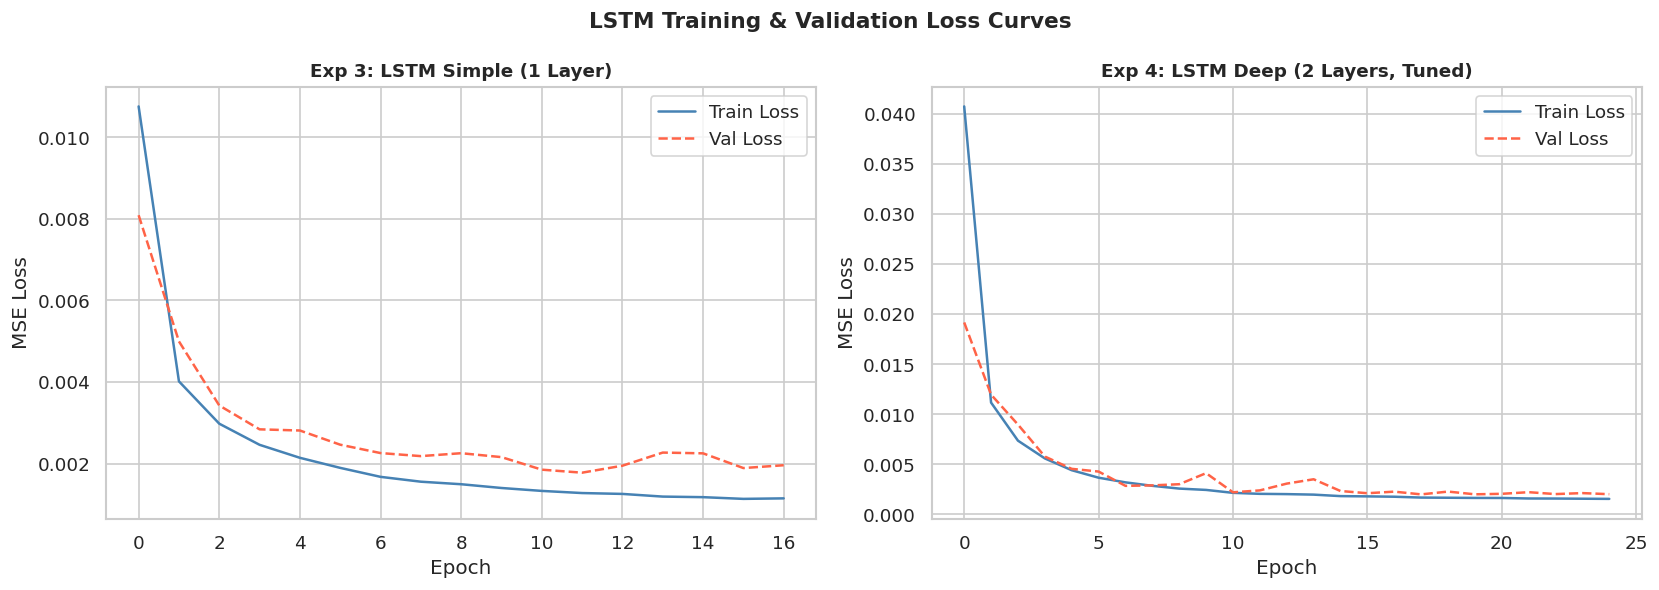

Saved: lstm_training_curves.png


In [28]:
# Plot 1: Training Loss Curves for both LSTMs
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, hist, title in zip(
    axes,
    [history_simple, history_deep],
    ['Exp 3: LSTM Simple (1 Layer)', 'Exp 4: LSTM Deep (2 Layers, Tuned)']
):
    ax.plot(hist.history['loss'],     label='Train Loss', color='steelblue')
    ax.plot(hist.history['val_loss'], label='Val Loss',   color='tomato', linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()

plt.suptitle('LSTM Training & Validation Loss Curves', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_training_curves.png', bbox_inches='tight')
plt.show()
print('Saved: lstm_training_curves.png')

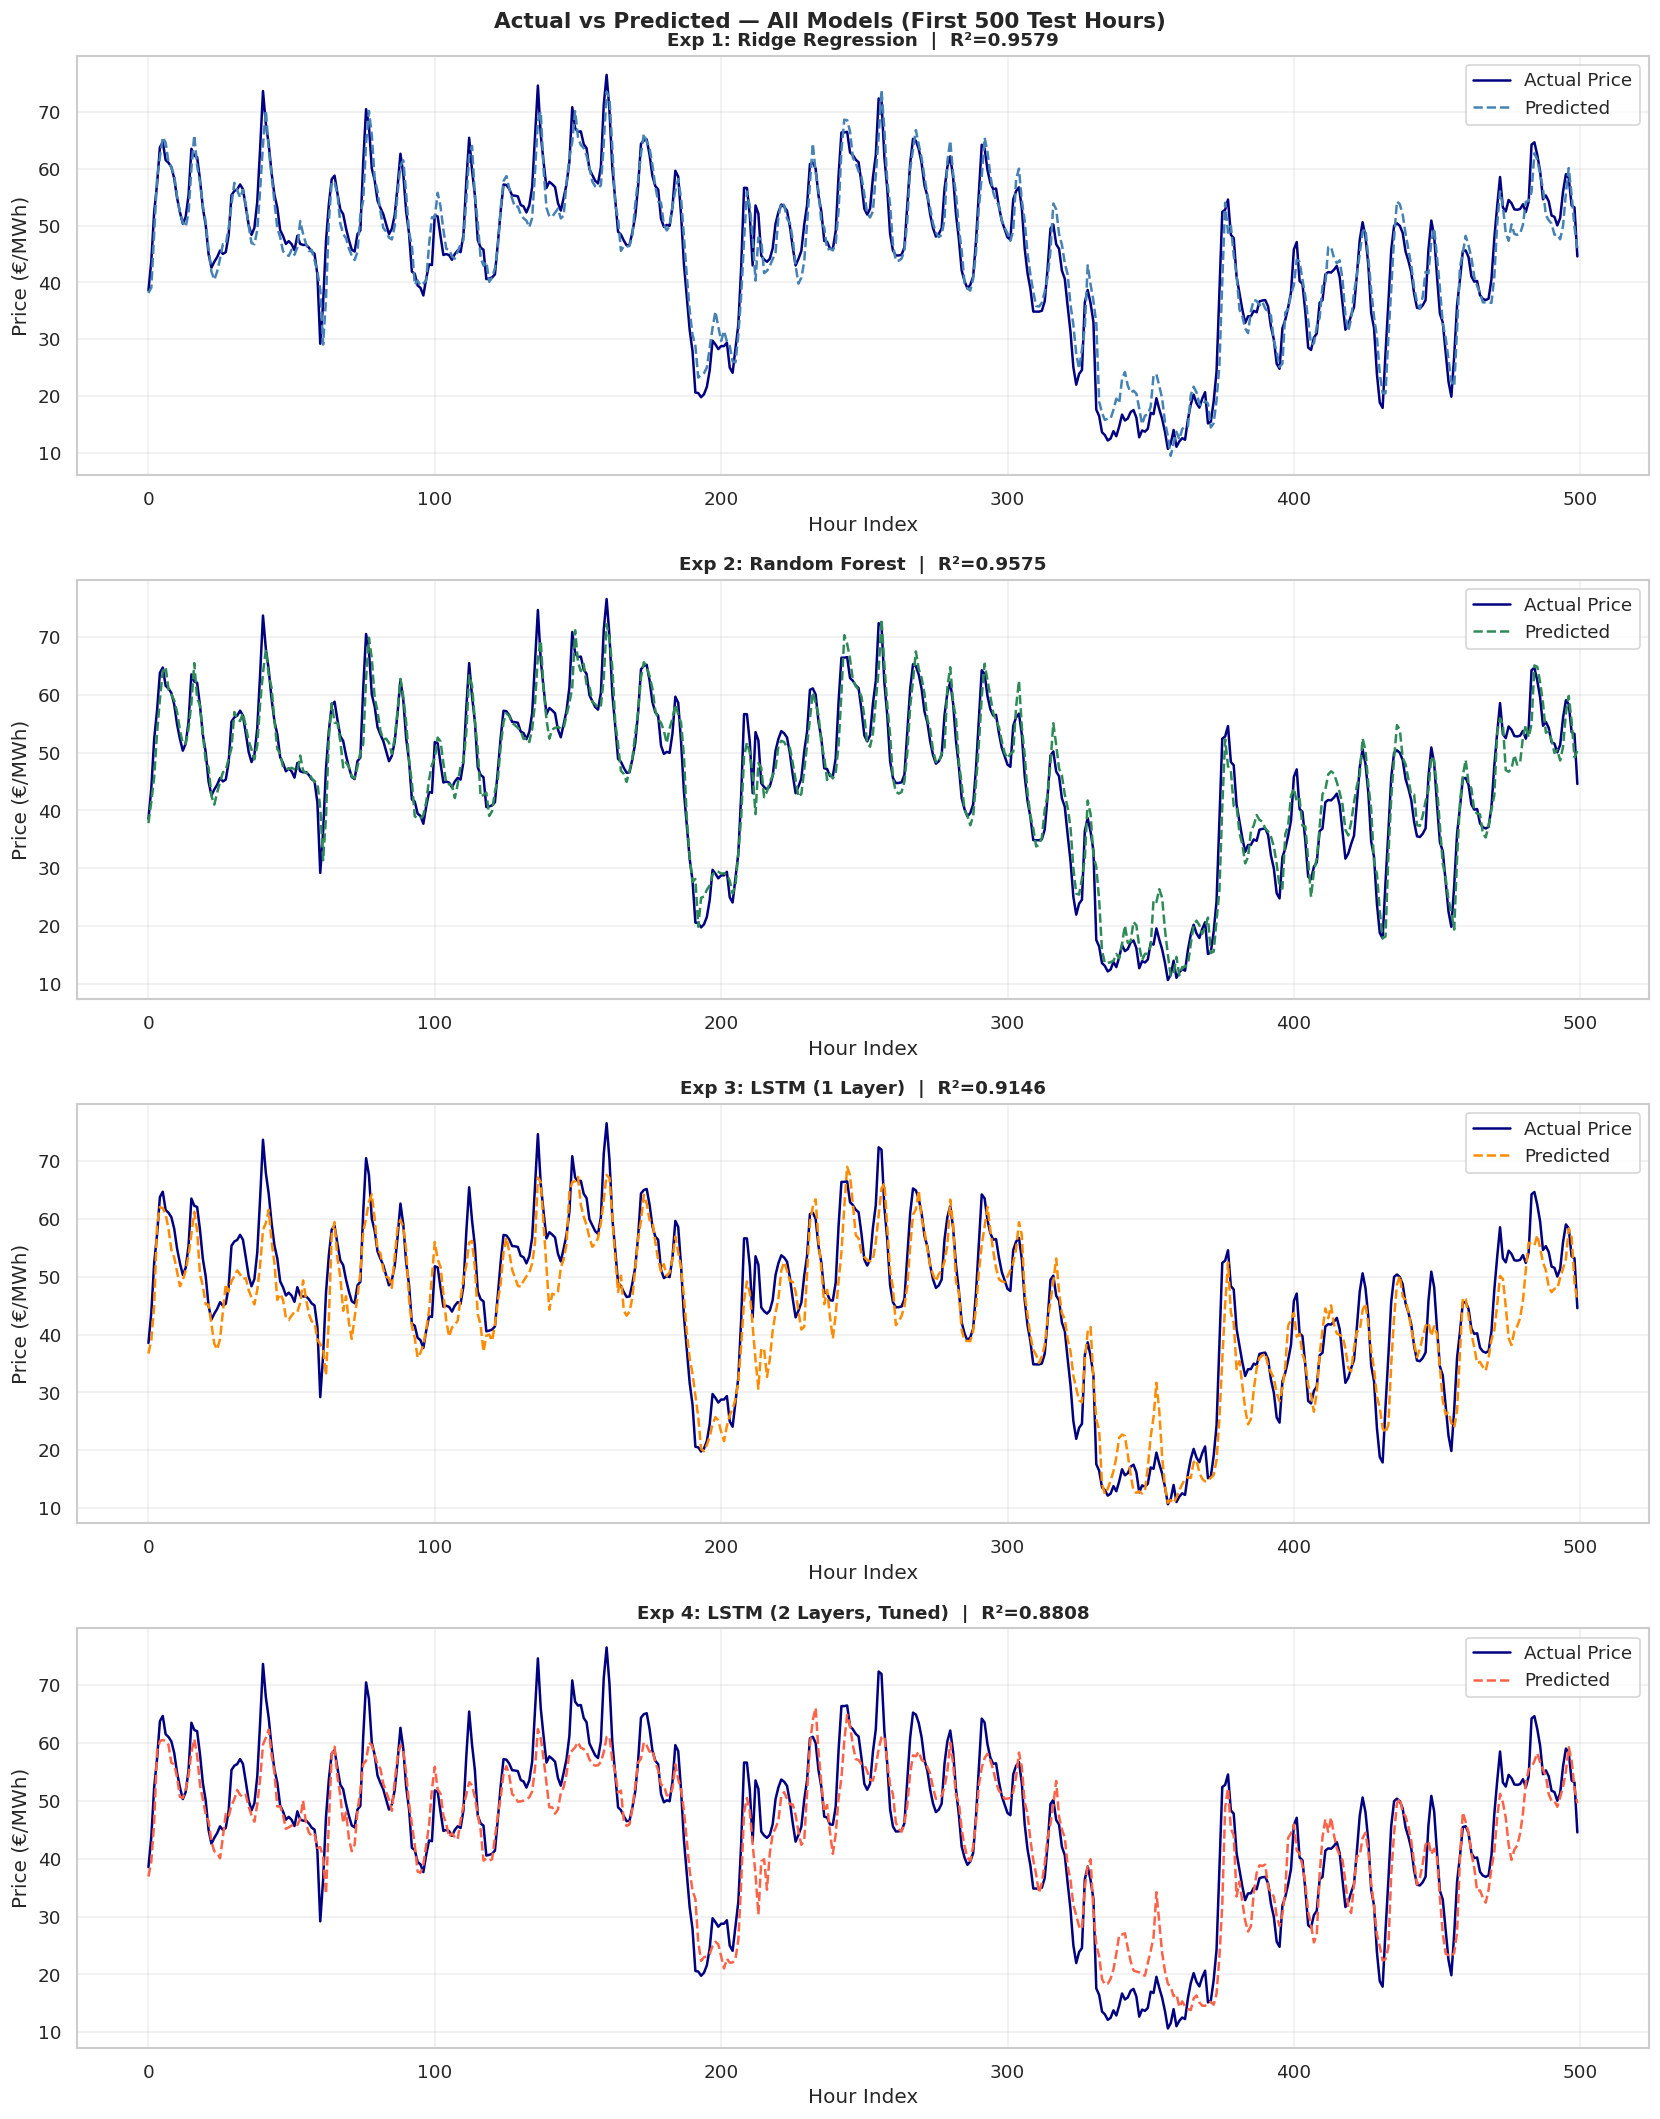

Saved: all_models_predictions.png


In [29]:
# Plot 2: Actual vs Predicted — All 4 Models
n = 500  # show first 500 test hours for clarity

fig, axes = plt.subplots(4, 1, figsize=(14, 18))

predictions = [
    (y_pred_ridge,       y_test,      'Exp 1: Ridge Regression',      'steelblue'),
    (y_pred_rf,          y_test,      'Exp 2: Random Forest',         'seagreen'),
    (y_pred_lstm_simple, y_test_lstm, 'Exp 3: LSTM (1 Layer)',        'darkorange'),
    (y_pred_lstm_deep,   y_test_lstm, 'Exp 4: LSTM (2 Layers, Tuned)','tomato'),
]

for ax, (y_pred, y_true, title, color) in zip(axes, predictions):
    ax.plot(y_true[:n],  label='Actual Price', color='navy',  linewidth=1.5)
    ax.plot(y_pred[:n],  label='Predicted',    color=color,   linewidth=1.5, linestyle='--')
    r2 = r2_score(y_true, y_pred)
    ax.set_title(f'{title}  |  R²={r2:.4f}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Price (€/MWh)')
    ax.set_xlabel('Hour Index')
    ax.legend(loc='upper right')
    ax.grid(alpha=0.3)

plt.suptitle('Actual vs Predicted — All Models (First 500 Test Hours)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('all_models_predictions.png', bbox_inches='tight')
plt.show()
print('Saved: all_models_predictions.png')

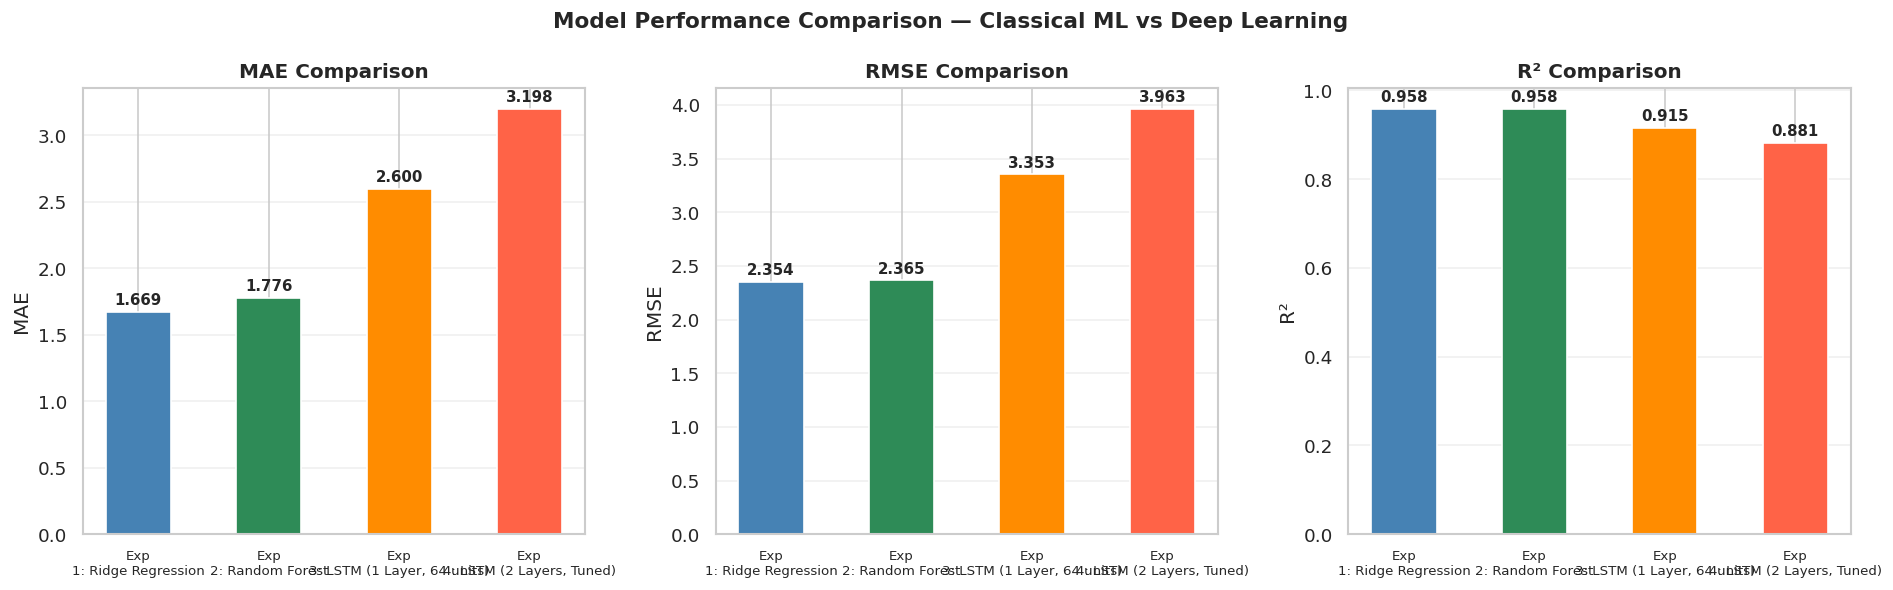

Saved: model_comparison_all.png


In [30]:
# Plot 3: Model Comparison Bar Chart
metrics = ['MAE', 'RMSE', 'R²']
models  = [r['Model'].replace('Exp ', 'Exp\n') for r in results_log]
colors  = ['steelblue', 'seagreen', 'darkorange', 'tomato']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    vals = [r[metric] for r in results_log]
    bars = ax.bar(models, vals, color=colors, edgecolor='white', width=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Model Performance Comparison — Classical ML vs Deep Learning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_all.png', bbox_inches='tight')
plt.show()
print('Saved: model_comparison_all.png')

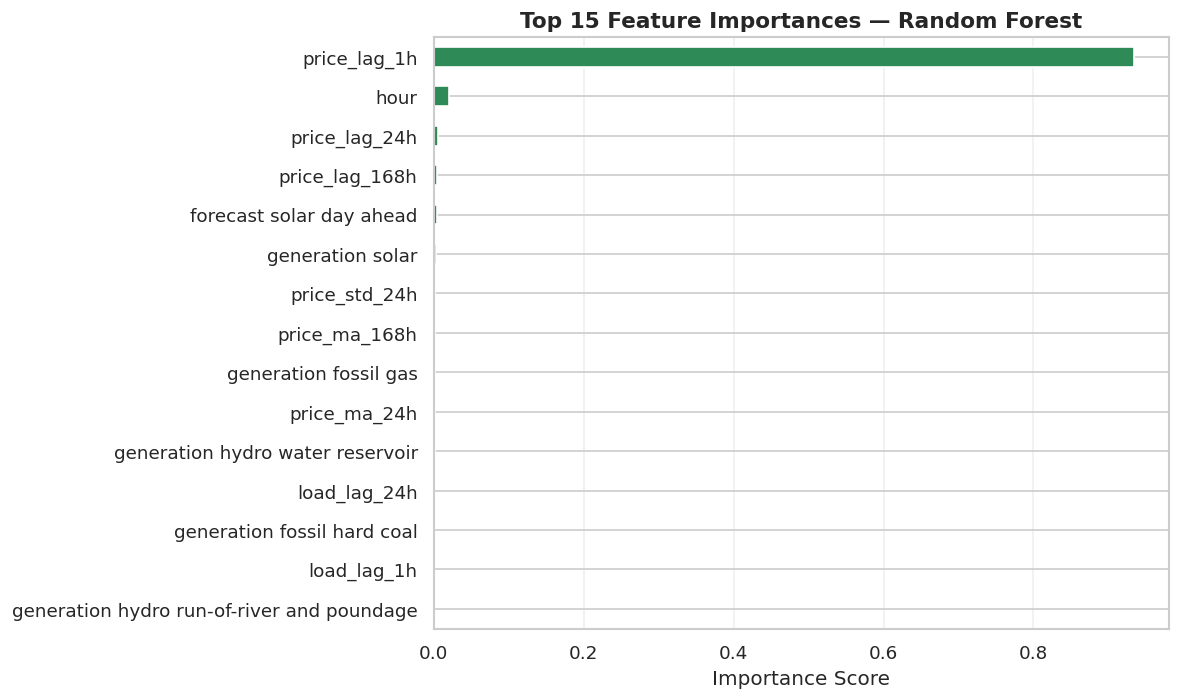

Saved: feature_importance.png


In [31]:
# Plot 4: Feature Importance (Random Forest)
feat_imp = pd.Series(best_rf.feature_importances_, index=FEATURES).nlargest(15)

plt.figure(figsize=(10, 6))
feat_imp.sort_values().plot(kind='barh', color='seagreen', edgecolor='white')
plt.title('Top 15 Feature Importances — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

---
## Save Feature Columns & Final Summary

In [32]:
with open('feature_columns.json', 'w') as f:
    json.dump(FEATURES, f)

print('\n Task 1C Complete!')
print('\n Saved models:')
print('  model_ridge.pkl')
print('  model_random_forest.pkl')
print('  model_lstm_simple.keras')
print('  model_lstm_deep.keras')
print('\n Saved scalers:')
print('  scaler_standard.pkl    (for classical ML)')
print('  scaler_minmax_X.pkl    (for LSTM features)')
print('  scaler_minmax_y.pkl    (for LSTM target)')
print('\n Saved metadata:')
print('  feature_columns.json')
print('\n  Saved plots:')
print('  lstm_training_curves.png')
print('  all_models_predictions.png')
print('  model_comparison_all.png')
print('  feature_importance.png')


 Task 1C Complete!

 Saved models:
  model_ridge.pkl
  model_random_forest.pkl
  model_lstm_simple.keras
  model_lstm_deep.keras   ← Best model

 Saved scalers:
  scaler_standard.pkl    (for classical ML)
  scaler_minmax_X.pkl    (for LSTM features)
  scaler_minmax_y.pkl    (for LSTM target)

 Saved metadata:
  feature_columns.json

  Saved plots:
  lstm_training_curves.png
  all_models_predictions.png
  model_comparison_all.png
  feature_importance.png


In [34]:
import shutil
shutil.copy('model_ridge.pkl', '/content/drive/MyDrive/Pipeline files/model_ridge.pkl')
shutil.copy('model_random_forest.pkl', '/content/drive/MyDrive/Pipeline files/model_random_forest.pkl')
shutil.copy('model_lstm_simple.keras', '/content/drive/MyDrive/Pipeline files/model_lstm_simple.keras')
shutil.copy('model_lstm_deep.keras', '/content/drive/MyDrive/Pipeline files/model_lstm_deep.keras')
shutil.copy('scaler_standard.pkl', '/content/drive/MyDrive/Pipeline files/scaler_standard.pkl')
shutil.copy('scaler_minmax_X.pkl', '/content/drive/MyDrive/Pipeline files/scaler_minmax_X.pkl')
shutil.copy('scaler_minmax_y.pkl', '/content/drive/MyDrive/Pipeline files/scaler_minmax_y.pkl')
shutil.copy('feature_columns.json', '/content/drive/MyDrive/Pipeline files/feature_columns.json')
print('All models saved to Google Drive!')

All models saved to Google Drive!
